# Tutorial: Quantum State Tomography with ErrorGnomark

Welcome to the `errorgnomark` state tomography tutorial. Quantum State Tomography (QST) is a fundamental procedure for fully characterizing an unknown quantum state. By performing measurements in a sufficient number of different bases, we can reconstruct the state's density matrix, `ρ`.

This process is invaluable for:
*   Verifying the output of a quantum algorithm.
*   Characterizing the state produced by a specific quantum circuit.
*   Diagnosing errors in state preparation.

This tutorial will guide you through using the `errorgnomark` framework to perform state tomography, analyze the results, and generate comprehensive reports.

## The `errorgnomark.tomography` Module: An Overview

The state tomography functionality in `errorgnomark` is designed to be both powerful and easy to use. It is primarily divided into two categories of experiments:

1.  **Arbitrary State Tomography (`ArbitraryStateTomographyExperiment`)**:
    *   **Purpose**: This is a general-purpose tool designed to reconstruct *any* quantum state.
    *   **Mechanism**: The user provides a `QuantumCircuit` that prepares the desired state. The experiment then automatically generates and executes the necessary measurement circuits to reconstruct the density matrix.
    *   **Use Case**: Ideal for characterizing custom states, such as the output of a small variational algorithm or a unique entangled state.

2.  **Graph State Tomography (e.g., `GraphStateTomographyExperiment`)**:
    *   **Purpose**: This is a specialized and optimized tool for characterizing **Graph States**, which are a crucial resource in measurement-based quantum computing.
    *   **Mechanism**: Instead of a circuit, the user specifies the graph structure. The experiment leverages this structure to efficiently perform tomography.
    *   **Use Case**: Best suited for applications involving cluster states or graph-based algorithms.

**Important Limitation**: The resources required for state tomography scale exponentially with the number of qubits (`n`). The number of measurements scales as `O(3^n)` and the classical processing scales as `O(4^n)`. Consequently, full state tomography is only feasible for a small number of qubits (typically n <= 5-6 in practice).

This tutorial will focus on the most common use case: **performing arbitrary state tomography on a 2-qubit system.**

## Setup: Imports and Project Structure

Before we begin, we need to import the necessary components from the `errorgnomark` library and standard Python packages. This first code block handles all the setup required for the experiments that follow.

In [1]:
import os
import sys
from datetime import datetime
import numpy as np
from typing import Dict, Tuple

# Ensure the project root is in the Python path to find the 'errorgnomark' package
# This is only necessary if you are running the script from the 'examples' directory
# and have not installed the package.
if '..' not in sys.path:
    sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__name__), '..')))

# --- Core components from the errorgnomark framework ---
from errorgnomark.circuits.circuit import QuantumCircuit, Gate
from errorgnomark.backends.base_backend import BaseBackend
from errorgnomark.backends.dummy_backend import DummyBackend
from errorgnomark.experiments.characterization.tomography.state_tomography.arbitrary_state_tomography import ArbitraryStateTomographyExperiment
from errorgnomark.analysis.reporting import generate_report, ExcelReport, plot_density_matrix

print("--- All necessary modules imported successfully. ---")

--- All necessary modules imported successfully. ---


## Part 1: Tomography of a Bell State with a Standard Backend

In this section, we will perform state tomography on a 2-qubit Bell state (`|Φ+⟩ = (|00⟩ + |11⟩)/√2`). We will use the built-in `DummyBackend`, which allows us to simulate a noisy quantum computer.

The process involves these key steps:
1.  **Setup**: Create a timestamped directory to store all results.
2.  **Initialize Backend**: Instantiate `DummyBackend` with a defined noise model (depolarizing and SPAM errors).
3.  **Define Target State**: Construct the quantum circuit that prepares the Bell state.
4.  **Run Experiment**: Execute the tomography experiment, which runs many circuits on the backend.
5.  **Analyze Results**: Use the built-in analysis tools to reconstruct the density matrix and calculate metrics like fidelity. This includes both full tomography and **Direct Fidelity Estimation (DFE)**.
6.  **Generate Reports**: Create a comprehensive Excel report and a plot of the density matrix.

=== PART 1: RUNNING DEMO WITH DEFAULT DummyBackend ===
--- All results will be saved in: results/tomography_dummy_backend_2025-09-11_17-13-18 ---

[Step 2] Initializing backend (Depolarizing: 0.005, SPAM: 0.01)...

[Step 3] Defining target state: Bell state on qubits [0, 1].

[Step 4] Running experiment to collect Pauli expectation values (8192 shots per basis)...
Starting ArbitraryStateTomographyExperiment with 8192 shots per basis.
Running circuit 1/16 (Basis: II)...
Running circuit 2/16 (Basis: IX)...
Running circuit 3/16 (Basis: IY)...
Running circuit 4/16 (Basis: IZ)...
Running circuit 5/16 (Basis: XI)...
Running circuit 6/16 (Basis: XX)...
Running circuit 7/16 (Basis: XY)...
Running circuit 8/16 (Basis: XZ)...
Running circuit 9/16 (Basis: YI)...
Running circuit 10/16 (Basis: YX)...
Running circuit 11/16 (Basis: YY)...
Running circuit 12/16 (Basis: YZ)...
Running circuit 13/16 (Basis: ZI)...
Running circuit 14/16 (Basis: ZX)...
Running circuit 15/16 (Basis: ZY)...
Running circuit 

/Users/ousiachai/Desktop/errgnomarkv2/errorgnomark/analysis/reporting.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


Density matrix plot saved to: results/tomography_dummy_backend_2025-09-11_17-13-18/reconstructed_density_matrix.png
-> Density matrix plot saved to: results/tomography_dummy_backend_2025-09-11_17-13-18/reconstructed_density_matrix.png


/Users/ousiachai/Desktop/errgnomarkv2/errorgnomark/analysis/reporting.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


-> Excel report saved to: results/tomography_dummy_backend_2025-09-11_17-13-18/tomography_report.xlsx.xlsx

[Step 7] Displaying final console summary...

               ANALYSIS REPORT

--- Result Set 1: Full Tomography & Fidelity ---
  Reconstruction Method: Linear Inversion
  Fidelity with Ideal State: 0.9565
  Purity of Reconstructed State: 0.9158
  Trace of Reconstructed Matrix: 1.0000

--- Result Set 2: Direct Fidelity Estimation ---
  Reconstruction Method: DFE from Pauli Expectation Values
  Fidelity with Ideal State: 0.9565
  Purity of Reconstructed State: 0.9158
  Trace of Reconstructed Matrix: 1.0000



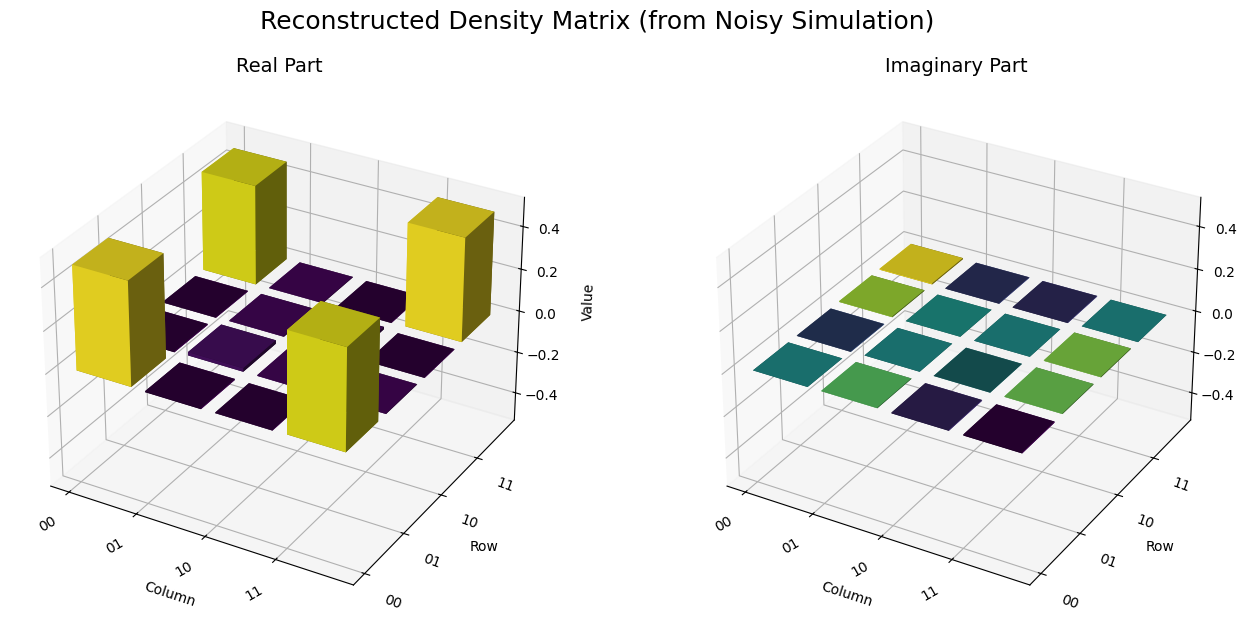

In [5]:
# ==============================================================================
# === PART 1: RUNNING DEMO WITH DEFAULT DummyBackend (as a direct script) ===
# ==============================================================================
print("="*80)
print("=== PART 1: RUNNING DEMO WITH DEFAULT DummyBackend ===")
print("="*80)

# --- [Step 1] Setup Results Directory ---
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
results_dir = os.path.join("results", f"tomography_dummy_backend_{timestamp}")
os.makedirs(results_dir, exist_ok=True)
print(f"--- All results will be saved in: {results_dir} ---")

# --- [Step 2] Initialize Backend with Noise ---
print("\n[Step 2] Initializing backend (Depolarizing: 0.005, SPAM: 0.01)...")
depolarizing_error = 0.005
spam_error = 0.01
backend = DummyBackend(depolarizing_error=depolarizing_error, spam_error=spam_error)

# --- [Step 3] Define Target State ---
print("\n[Step 3] Defining target state: Bell state on qubits [0, 1].")
qubits_to_test = [0, 1]
bell_circuit = QuantumCircuit(qubits=qubits_to_test)
bell_circuit.add_gate(Gate('h', (0,)))
bell_circuit.add_gate(Gate('cnot', (0, 1)))

# --- [Step 4] Run Tomography Experiment ---
print("\n[Step 4] Running experiment to collect Pauli expectation values (8192 shots per basis)...")
shots_per_basis = 8192
experiment = ArbitraryStateTomographyExperiment(qubits=qubits_to_test, state_prep_circuit=bell_circuit)
experiment.run(backend, shots=shots_per_basis)
raw_data = experiment.experiment_data

# --- [Step 5] Analyze the results using different methods ---
print("\n[Step 5] Analyzing the results...")
analysis_tool = experiment.analysis_tool

# Define the ideal state for comparison
ideal_bell_vector = (1/np.sqrt(2)) * np.array([1, 0, 0, 1])
ideal_bell_rho = np.outer(ideal_bell_vector, ideal_bell_vector.conj())

# Perform both full tomography and Direct Fidelity Estimation (DFE)
result_tomography = analysis_tool.analyze(experiment_data=raw_data, ideal_density_matrix=ideal_bell_rho)
result_dfe = analysis_tool.analyze(experiment_data=raw_data, target_state_vector=ideal_bell_vector)
analysis_results = [result_tomography, result_dfe]

# --- [Step 6] Generate All Reports and Outputs ---
print("\n[Step 6] Generating all reports and output files...")

# Save the measurement bases used in the experiment
bases_filepath = os.path.join(results_dir, "measurement_bases.txt")
with open(bases_filepath, 'w') as f:
    for basis in experiment.measurement_bases:
        f.write(f"{basis}\n")
print(f"-> Measurement bases saved to: {bases_filepath}")

# Generate and save a plot of the reconstructed density matrix
plot_save_path = os.path.join(results_dir, "reconstructed_density_matrix.png")
plot_density_matrix(
    rho=result_tomography.reconstructed_rho,
    title="Reconstructed Density Matrix (from Noisy Simulation)",
    save_path=plot_save_path
)
print(f"-> Density matrix plot saved to: {plot_save_path}")

# Create and save a multi-sheet Excel report
report = ExcelReport(results_dir)
report.create_summary_sheet(
    analysis_results=analysis_results,
    experiment_params={
        "Target State": "Bell State |Φ+⟩",
        "Qubits": qubits_to_test,
        "Shots per Basis": shots_per_basis,
        "Depolarizing Error": depolarizing_error,
        "SPAM Error": spam_error,
        "Backend": "DummyBackend"
    }
).add_raw_data_sheet(
    experiment_data=raw_data
).add_probabilities_sheet(
    experiment_data=raw_data
).add_density_matrix_plot(
    rho=result_tomography.reconstructed_rho,
    sheet_name="Reconstructed Density Matrix"
)
report_path = report.save("tomography_report")
print(f"-> Excel report saved to: {report_path}")

# --- Final Console Report ---
print("\n[Step 7] Displaying final console summary...")
generate_report(analysis_results)

## Part 2: Advanced Usage - Integrating a Custom Backend

The `errorgnomark` framework is extensible. A key feature is the ability to define your own backend by inheriting from the `BaseBackend` abstract class. This allows you to:
*   Interface with new quantum hardware or simulators.
*   Implement custom, complex noise models for research purposes.
*   Test analysis routines against a known, controlled source of error.

Below, we define `CustomSimulatorBackend`, a simple backend that applies a bit-flip error to the measurement outcomes of an ideal simulation. This demonstrates the process of implementing the `run` method required by the `BaseBackend` interface.

In [6]:
class CustomSimulatorBackend(BaseBackend):
    """
    An example custom backend that simulates a new device with a specific, 
    simple noise model. This class demonstrates how to implement the BaseBackend interface.
    
    Noise Model: A simple bit-flip probability is applied AFTER an ideal simulation.
    """
    def __init__(self, bit_flip_error: float = 0.02):
        if not (0 <= bit_flip_error <= 1):
            raise ValueError("Bit-flip error must be between 0 and 1.")
        self.bit_flip_error = bit_flip_error
        print(f"[CustomBackend] Initialized with bit-flip error = {self.bit_flip_error}")

    def run(self, circuit: QuantumCircuit, shots: int) -> Tuple[Dict[str, float], Dict[str, int]]:
        """
        Executes the circuit, gets ideal probabilities, and then applies bit-flip noise.
        
        Returns:
            A tuple containing (ideal_probabilities, noisy_counts).
        """
        # Step 1: Get the ideal results using a noiseless DummyBackend.
        temp_ideal_backend = DummyBackend(depolarizing_error=0, spam_error=0)
        ideal_statevector = temp_ideal_backend._simulate(circuit)
        ideal_probabilities = temp_ideal_backend._get_probabilities_from_statevector(ideal_statevector)

        # Step 2: Calculate the noisy probability distribution by applying the bit-flip channel.
        num_qubits = len(circuit.qubits)
        noisy_probabilities = {format(i, f'0{num_qubits}b'): 0.0 for i in range(2**num_qubits)}

        for ideal_outcome, ideal_prob in ideal_probabilities.items():
            if ideal_prob < 1e-9:
                continue
            
            # For each ideal outcome, calculate the probability of it flipping to any other outcome.
            for i in range(2**num_qubits):
                noisy_outcome = format(i, f'0{num_qubits}b')
                num_flips = sum(c1 != c2 for c1, c2 in zip(ideal_outcome, noisy_outcome))
                
                # Binomial probability of this specific flip event occurring
                prob_of_this_flip = (self.bit_flip_error ** num_flips) * \
                                    ((1 - self.bit_flip_error) ** (num_qubits - num_flips))
                
                noisy_probabilities[noisy_outcome] += ideal_prob * prob_of_this_flip

        # Step 3: Sample from the final noisy distribution to get counts.
        noisy_counts = temp_ideal_backend._sample_from_probabilities(noisy_probabilities, shots)
        
        return (ideal_probabilities, noisy_counts)

print("--- CustomSimulatorBackend class defined. ---")

--- CustomSimulatorBackend class defined. ---


Now, we will repeat the entire tomography workflow, but this time, we will replace the `DummyBackend` with our new `CustomSimulatorBackend`. The experimental and analysis code remains nearly identical, showcasing the modularity of the framework.



=== PART 2: RUNNING DEMO WITH CUSTOM USER-DEFINED BACKEND ===
--- All results will be saved in: results/tomography_custom_backend_2025-09-11_17-15-12 ---

[Step 2] Initializing CustomSimulatorBackend...
[CustomBackend] Initialized with bit-flip error = 0.015

[Step 3] Defining target state: Bell state on qubits [0, 1].

[Step 4] Running experiment on the custom backend (8192 shots per basis)...
Starting ArbitraryStateTomographyExperiment with 8192 shots per basis.
Running circuit 1/16 (Basis: II)...
Running circuit 2/16 (Basis: IX)...
Running circuit 3/16 (Basis: IY)...
Running circuit 4/16 (Basis: IZ)...
Running circuit 5/16 (Basis: XI)...
Running circuit 6/16 (Basis: XX)...
Running circuit 7/16 (Basis: XY)...
Running circuit 8/16 (Basis: XZ)...
Running circuit 9/16 (Basis: YI)...
Running circuit 10/16 (Basis: YX)...
Running circuit 11/16 (Basis: YY)...
Running circuit 12/16 (Basis: YZ)...
Running circuit 13/16 (Basis: ZI)...
Running circuit 14/16 (Basis: ZX)...
Running circuit 15/1

/Users/ousiachai/Desktop/errgnomarkv2/errorgnomark/analysis/reporting.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


Density matrix plot saved to: results/tomography_custom_backend_2025-09-11_17-15-12/reconstructed_density_matrix_custom.png
-> Density matrix plot saved to: results/tomography_custom_backend_2025-09-11_17-15-12/reconstructed_density_matrix_custom.png


/Users/ousiachai/Desktop/errgnomarkv2/errorgnomark/analysis/reporting.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


-> Excel report for custom run saved to: results/tomography_custom_backend_2025-09-11_17-15-12/tomography_report_custom.xlsx.xlsx

[Step 7] Displaying final console summary for the custom run...

               ANALYSIS REPORT

--- Result Set 1: Full Tomography & Fidelity ---
  Reconstruction Method: Linear Inversion
  Fidelity with Ideal State: 0.9554
  Purity of Reconstructed State: 0.9137
  Trace of Reconstructed Matrix: 1.0000

--- Result Set 2: Direct Fidelity Estimation ---
  Reconstruction Method: DFE from Pauli Expectation Values
  Fidelity with Ideal State: 0.9554
  Purity of Reconstructed State: 0.9137
  Trace of Reconstructed Matrix: 1.0000



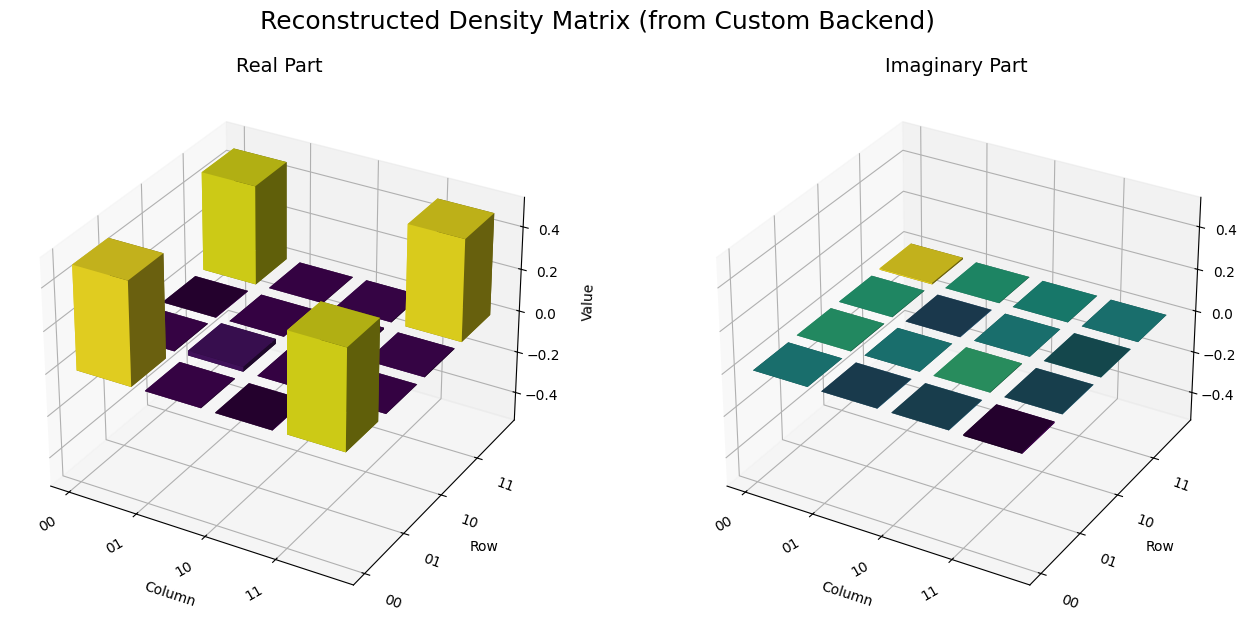

In [8]:
# ====================================================================================
# === PART 2: RUNNING DEMO WITH CUSTOM BACKEND (as a direct script) ===
# ====================================================================================
print("\n\n" + "="*80)
print("=== PART 2: RUNNING DEMO WITH CUSTOM USER-DEFINED BACKEND ===")
print("="*80)

# --- [Step 1] Setup Results Directory ---
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
results_dir = os.path.join("results", f"tomography_custom_backend_{timestamp}")
os.makedirs(results_dir, exist_ok=True)
print(f"--- All results will be saved in: {results_dir} ---")

# --- [Step 2] Initialize our CustomSimulatorBackend ---
# Note: The CustomSimulatorBackend class must have been defined in a previous cell.
print("\n[Step 2] Initializing CustomSimulatorBackend...")
custom_backend = CustomSimulatorBackend(bit_flip_error=0.015)

# --- [Step 3] Define Target State (same as before) ---
print("\n[Step 3] Defining target state: Bell state on qubits [0, 1].")
qubits_to_test = [0, 1]
bell_circuit = QuantumCircuit(qubits=qubits_to_test)
bell_circuit.add_gate(Gate('h', (0,)))
bell_circuit.add_gate(Gate('cnot', (0, 1)))

# --- [Step 4] Run Experiment on the Custom Backend ---
print("\n[Step 4] Running experiment on the custom backend (8192 shots per basis)...")
shots_per_basis = 8192
experiment = ArbitraryStateTomographyExperiment(qubits=qubits_to_test, state_prep_circuit=bell_circuit)
experiment.run(custom_backend, shots=shots_per_basis)
raw_data = experiment.experiment_data

# --- [Step 5] Analyze the results ---
print("\n[Step 5] Analyzing the results from the custom backend...")
analysis_tool = experiment.analysis_tool
ideal_bell_vector = (1/np.sqrt(2)) * np.array([1, 0, 0, 1])
ideal_bell_rho = np.outer(ideal_bell_vector, ideal_bell_vector.conj())
result_tomography = analysis_tool.analyze(experiment_data=raw_data, ideal_density_matrix=ideal_bell_rho)
result_dfe = analysis_tool.analyze(experiment_data=raw_data, target_state_vector=ideal_bell_vector)
analysis_results = [result_tomography, result_dfe]

# --- [Step 6] Generate Reports for the Custom Run ---
print("\n[Step 6] Generating all reports and output files for the custom run...")

# --- [NEW CODE ADDED HERE] ---
# Generate and save a standalone plot of the reconstructed density matrix.
# We give it a unique name to distinguish it from the plot in Part 1.
plot_save_path = os.path.join(results_dir, "reconstructed_density_matrix_custom.png")
plot_density_matrix(
    rho=result_tomography.reconstructed_rho,
    title="Reconstructed Density Matrix (from Custom Backend)",
    save_path=plot_save_path
)
print(f"-> Density matrix plot saved to: {plot_save_path}")
# --- [END OF NEW CODE] ---

# Create and save the multi-sheet Excel report (which also contains the plot).
report = ExcelReport(results_dir)
report.create_summary_sheet(
    analysis_results=analysis_results,
    experiment_params={
        "Target State": "Bell State |Φ+⟩",
        "Qubits": qubits_to_test,
        "Shots per Basis": shots_per_basis,
        "Custom Noise": f"Bit-Flip Error = {custom_backend.bit_flip_error}",
        "Backend": "CustomSimulatorBackend"
    }
).add_raw_data_sheet(
    experiment_data=raw_data
).add_probabilities_sheet(
    experiment_data=raw_data
).add_density_matrix_plot(
    rho=result_tomography.reconstructed_rho,
    sheet_name="Reconstructed Density Matrix"
)
report_path = report.save("tomography_report_custom")
print(f"-> Excel report for custom run saved to: {report_path}")

# --- [Step 7] Displaying final console summary ---
print("\n[Step 7] Displaying final console summary for the custom run...")
generate_report(analysis_results)